In [26]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

SEED = 12

az.style.use("arviz-doc")

Usamos el mismo dataset de ventas de una pizzería

In [2]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [44]:
pizza['order_hour'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S').dt.hour
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

Filtramos para reducir la cantidad de datos

In [32]:
pizza.query('order_date >= "2015-06-01" & order_date < "2015-07-01"', inplace=True)

Vamos a buscar modelar la cantidad de ventas por hora del día

In [33]:
conteo = pizza.groupby(['order_date', 'order_hour']).size().reset_index(name='sales')
conteo

,order_date,order_hour,sales
0,2015-06-01,11,12
1,2015-06-01,12,42
2,2015-06-01,13,11
3,2015-06-01,14,18
4,2015-06-01,15,25
...,...,...,...
348,2015-06-30,18,12
349,2015-06-30,19,2
350,2015-06-30,20,9
351,2015-06-30,21,5


In [34]:
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.95, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

X tiene que tener dos dimensiones, por eso el doble corchete

In [35]:
X = conteo[['order_hour']].values
y = conteo['sales'].values

Se suele usar m=10 y c=1.5

In [36]:
with pm.Model() as model_hsgp:
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(X))

    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    gp = pm.gp.HSGP(m=[10], c=1.5, cov_func=cov)

    f = gp.prior('f', X=X)
    α = pm.HalfNormal('α', 1)
    
    y_obs = pm.NegativeBinomial("y_obs", np.exp(f), α, observed=y)

    idata_hsgp = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ℓ, f_hsgp_coeffs, α]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 148 seconds.


In [37]:
az.summary(idata_hsgp, var_names=['ℓ', 'α'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ℓ,2.405,0.247,1.902,2.827,0.007,0.007,1397.0,1499.0,1.0
α,4.284,0.405,3.522,5.044,0.006,0.007,4976.0,3039.0,1.0


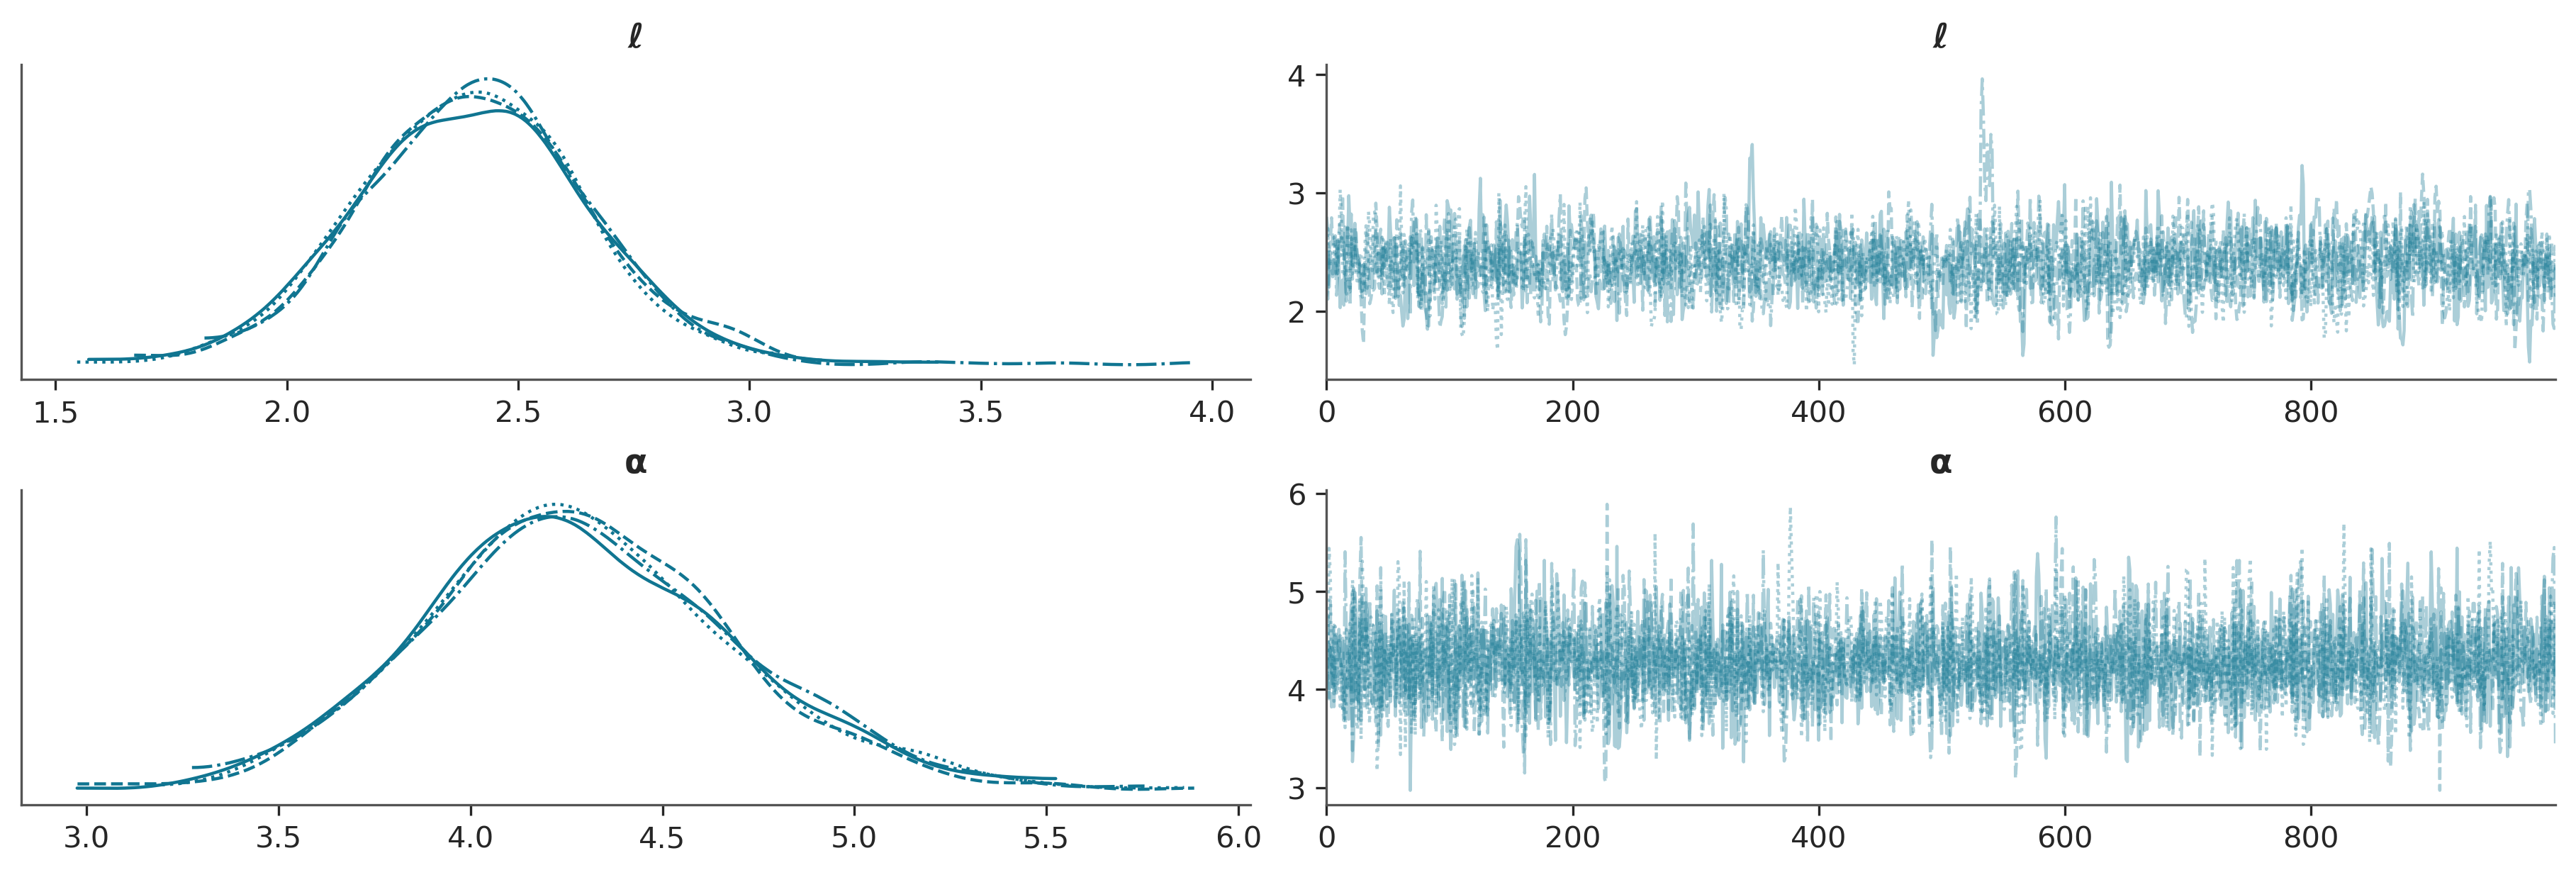

In [43]:
az.plot_trace(idata_hsgp, var_names=["ℓ", "α"]);

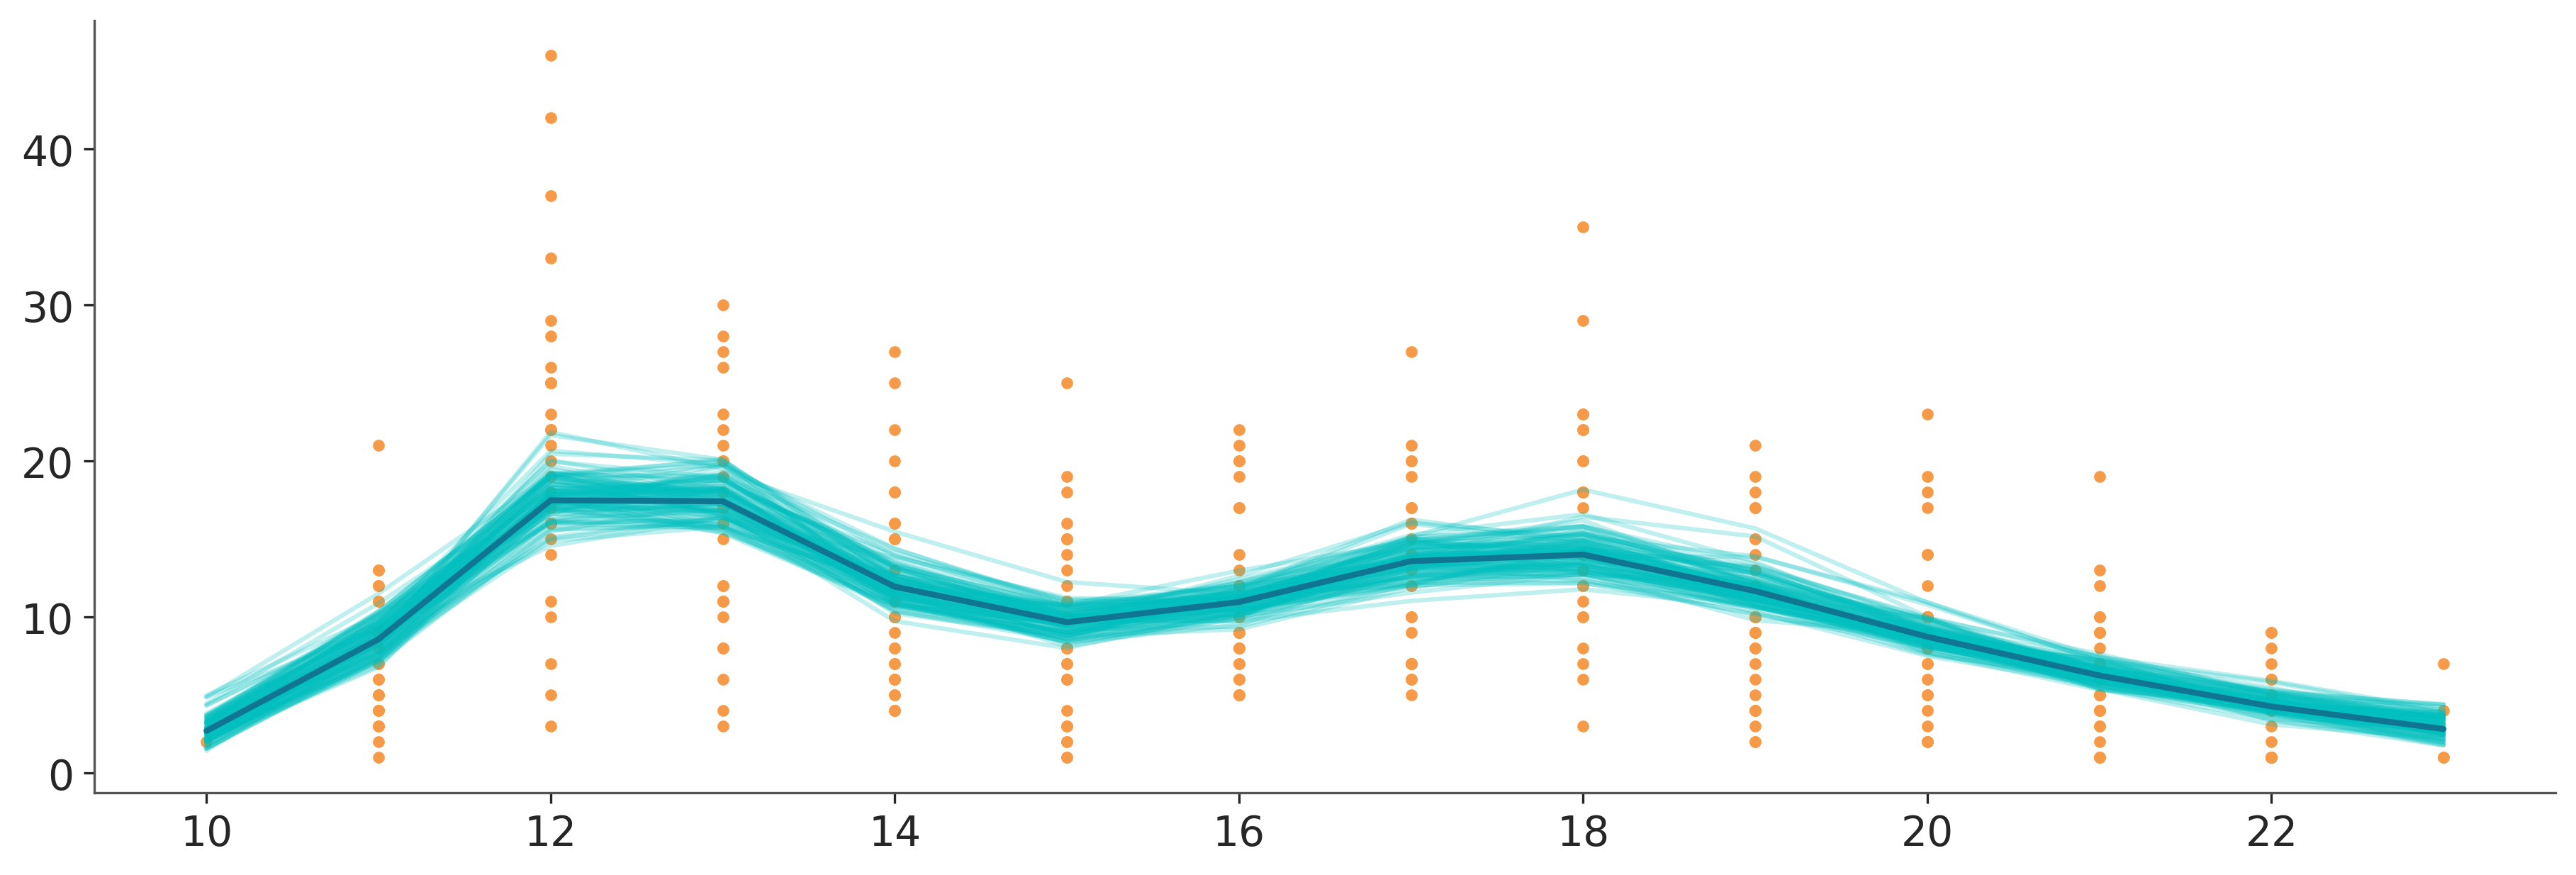

In [39]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(conteo["order_hour"].values, conteo["sales"].values, "C2.")


f = az.extract(idata_hsgp, group="posterior", var_names="f")
idx = np.argsort(X[:,0])
ax.plot(conteo["order_hour"].values[idx], np.exp(f.values[idx,:100]), alpha=0.25, color="C1")

ax.plot(conteo["order_hour"].values[idx], np.exp(f.values[idx].mean(1)), color="C0", lw=2);